# 04 · 进阶:打浦桥 24 小时协商弄堂算子
本册把研究地点切到**打浦桥街道 / 田子坊**。这里叠加了石库门里弄、原住居民、小商户与创意工作室、文旅消费、游客流量和社区治理。

这次不让单一主体胜出,而是把**通行、界面、时间与安全**转译成可以协商的空间权利:同一批建筑在不同时间与客流状态下,可以长出不同的形态安排。

> 数据、角色、读法都和主册一样;变的是——**权力现在可以改几何、界面与时间,不只是高度**。


## 怎么执行
- 点一格,按 **Shift+Enter** 执行;或选单 Run → Run All Cells 从头跑。
- 结果与图会显示在该格下面。代码都在 `engine/` 文件夹,平时不用打开。

In [1]:
# 让 notebook 找到 engine 里的代码(这格不用改,直接执行)
import sys, os
sys.path.insert(0, os.path.abspath("engine"))
# 清掉旧的引擎模块缓存:改了 config/engine 后,重跑本格即刻生效(免重启内核)
for _m in [k for k in list(sys.modules) if k in ("config", "common", "operators", "measure")
           or k == "plots" or k.startswith("plots.") or k == "prints" or k.startswith("prints.")]:
    del sys.modules[_m]
import config, common as C, plots, prints
prints.ready()
plots.capture("04")   # 开启自动存图:本册每张图都会存到 out/<slug>/Step_04/<时间戳>/

就绪 ·  当前站点 SLUG = dapuqiao ( 打浦桥街道 )


'20260701_171047'

In [2]:
import operators as ops, measure as M
assert config.SLUG == "dapuqiao", "请先把 config.py 的 SLUG 改成 dapuqiao 后重跑准备格"
df = C.assign_all(C.current_buildings(config.SLUG))
recs = C.to_recs(df)            # 算子的工作单位:[{geom, h, sh, frozen}]
prints.vocab(recs)


打浦桥街道 · 1370 栋。算子词汇:
   ['freeze', 'weight_height', 'concentrate', 'split_to_towers', 'slim', 'densify', 'infill', 'level', 'open_ground', 'taper', 'linear_slab', 'courtyard_open', 'uniform_cohort', 'twist', 'freeze_tags', 'micro_lease', 'frontage_quota', 'crowd_valve', 'night_reversion']


## 一、14 个原子算子 = power 对 form 的"动词"
| 算子 | 做什么 | 谁常用 |
|---|---|---|
| `freeze` | 锁定不动 | state / 居民核心 |
| `weight_height` | 按权重重分配高度 | 政府集权 |
| `concentrate` | 高度向权力重心收拢 | 政府集权(单峰) |
| `split_to_towers` | 大板楼拆成 k 座塔 | 开发商 / 文旅资本 |
| `slim` | footprint 缩、高度补偿(塔化) | 开发商 |
| `densify` | 抬高度 = 加 GFA | 开发商 |
| `infill` | 大体量细分成自建小单元 | 居民自建 |
| `level` | 高度趋同 | 居民 / 共享 |
| `open_ground` | 缩私有 footprint 释放共享地面 | 共享平权 / 消防疏散 |
| `freeze_tags` | 按 heritage / residential_core / emergency_access 等标签冻结 | 遗产与安全保护 |
| `micro_lease` | 把大商业体量拆成低租金、小商户、居民服务、文化展示单元 | 小商户 / 创意工作室 |
| `frontage_quota` | 限制游客主线界面被旅游消费独占 | 社区治理 |
| `crowd_valve` | 高峰客流下压缩商业占用、释放疏散节点 | 消防 / 疏散 |
| `night_reversion` | 夜间把部分消费界面与支弄归还居民 | 居民安静权 |

每个都是纯函数 `recs -> recs`,参数可改、可单独演示。下面先看两个通用动词,再看打浦桥新增动词。


## 二、算子图谱:单个动词的 before / after
**拆板成塔** `split_to_towers`:把大 footprint 沿长轴拆成 3 块(高度不变 → GFA 守恒)。


  -> saved out\dapuqiao\Step_04\20260701_171047\01_operator_demo.png


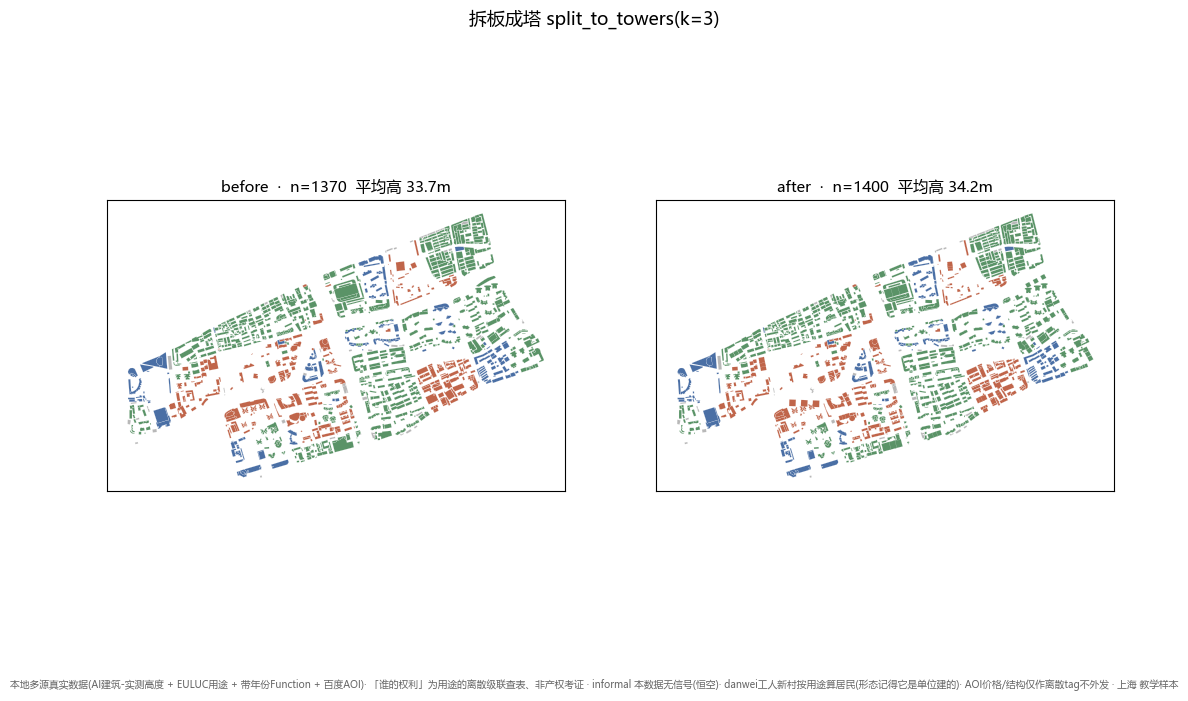

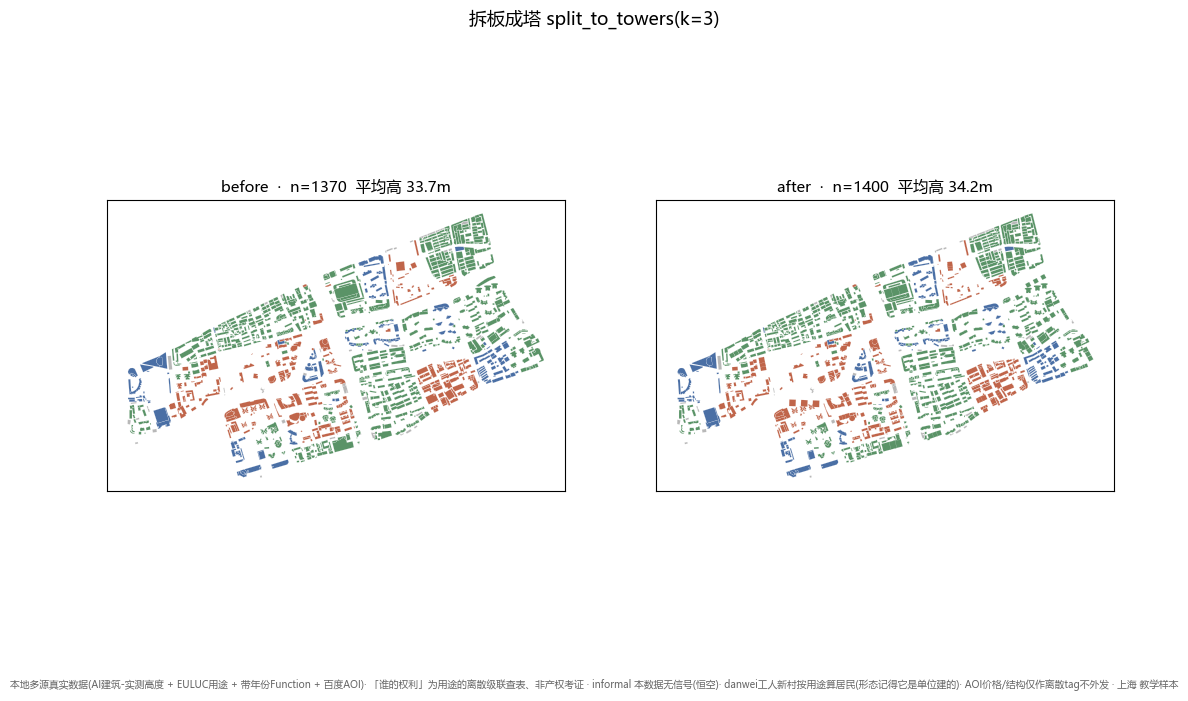

In [3]:
b = ops.freeze(recs, who=["state"])                                   # 先锁定政府公共
a = ops.split_to_towers(b, target=["resident", "developer"], above_m2=1500, k=3)
plots.operator_demo(b, a, "拆板成塔 split_to_towers(k=3)")

**居民自建** `infill`:把大体量细分成自建小单元(细粒、低层、有机)。看栋数怎么暴涨。

  -> saved out\dapuqiao\Step_04\20260701_171047\02_operator_demo.png


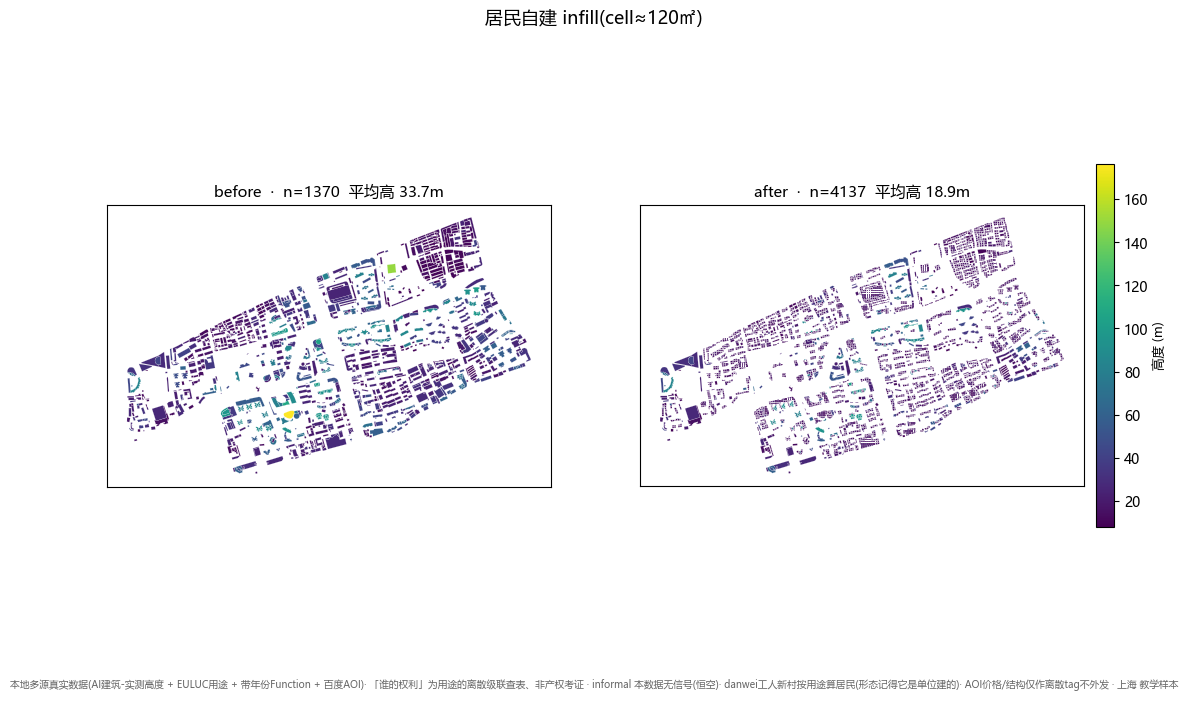

  -> saved out\dapuqiao\Step_04\20260701_171047\03_operator_demo.png


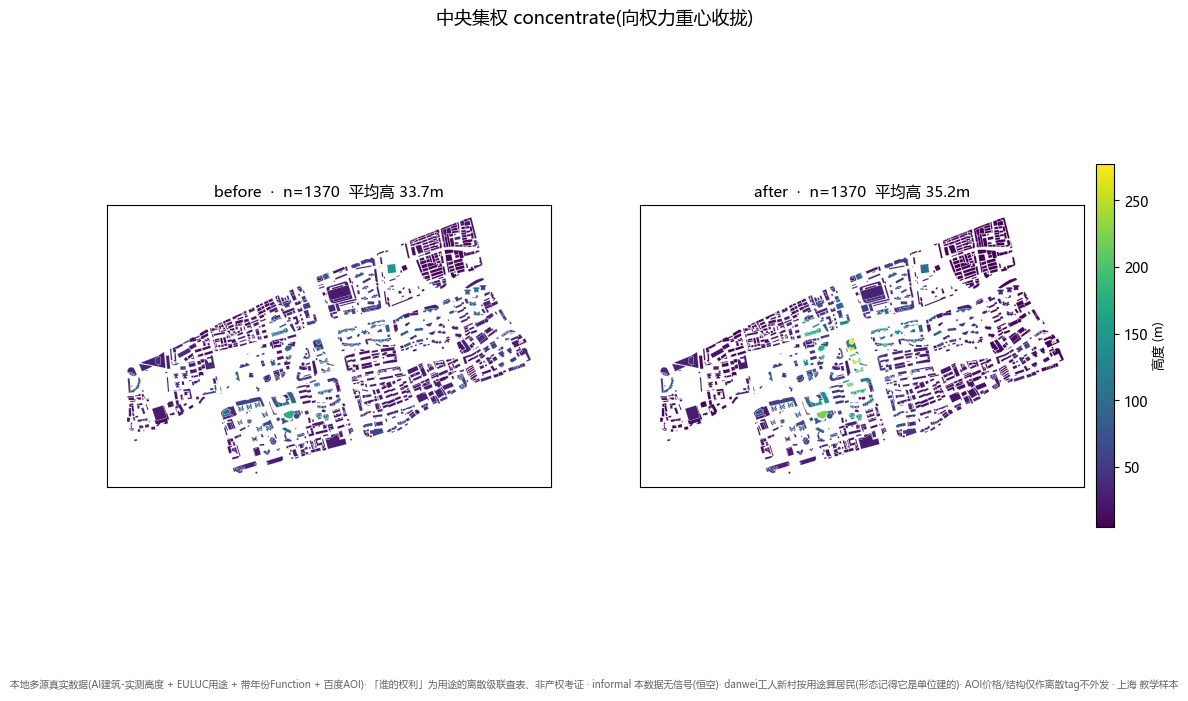

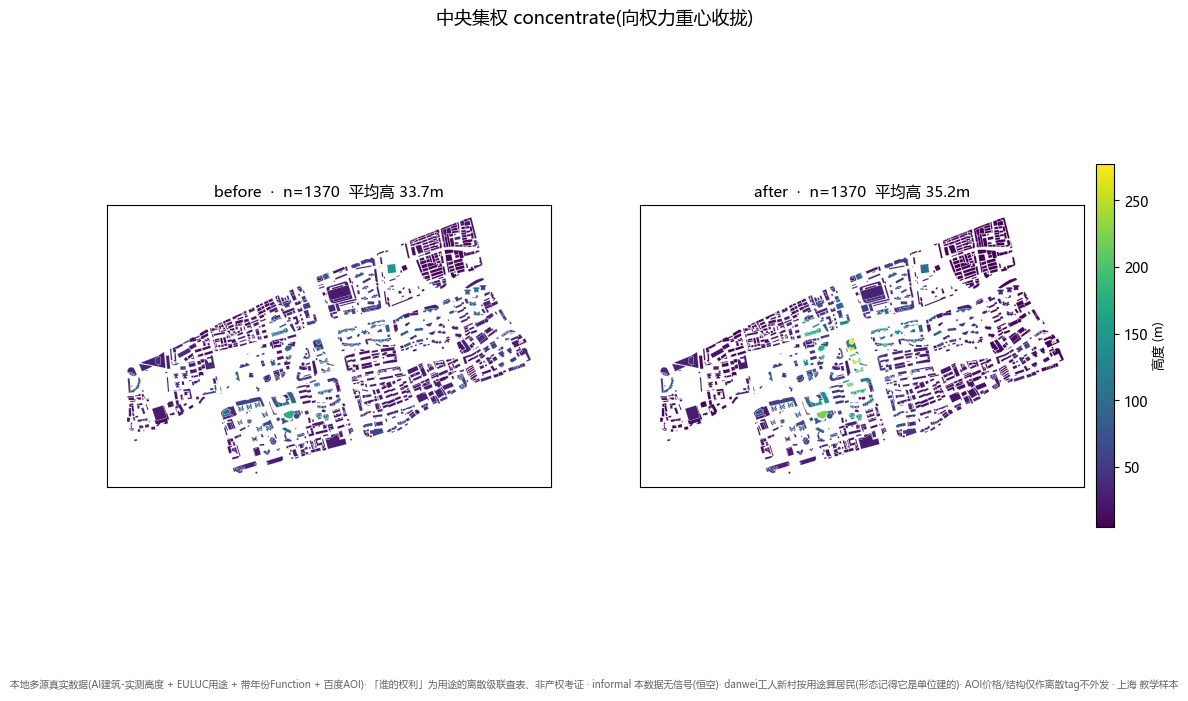

In [4]:
a2 = ops.infill(b, target=["resident", "developer"], cell_m2=120, min_h=6, max_h=21)
plots.operator_demo(b, a2, "居民自建 infill(cell≈120㎡)", color="h")
ac = ops.concentrate(b)
plots.operator_demo(b, ac, "中央集权 concentrate(向权力重心收拢)", color="h")


## 三、打浦桥新增算子:把通行、界面、时间与安全变成权利
下面单独展示 5 个新增算子。它们不是替代前面的高度/形态动词,而是把田子坊的协商对象进一步拆开:

- `freeze_tags`:先冻结历史里弄、居民核心、消防通道。
- `micro_lease`:把大商业体量拆成小商户、居民服务与文化展示单元。
- `frontage_quota`:限制游客主线界面被旅游消费独占。
- `crowd_valve`:高峰客流下释放疏散节点和单向通行。
- `night_reversion`:夜间把部分消费界面和支弄归还居民。


  -> saved out\dapuqiao\Step_04\20260701_171047\04_operator_demo.png


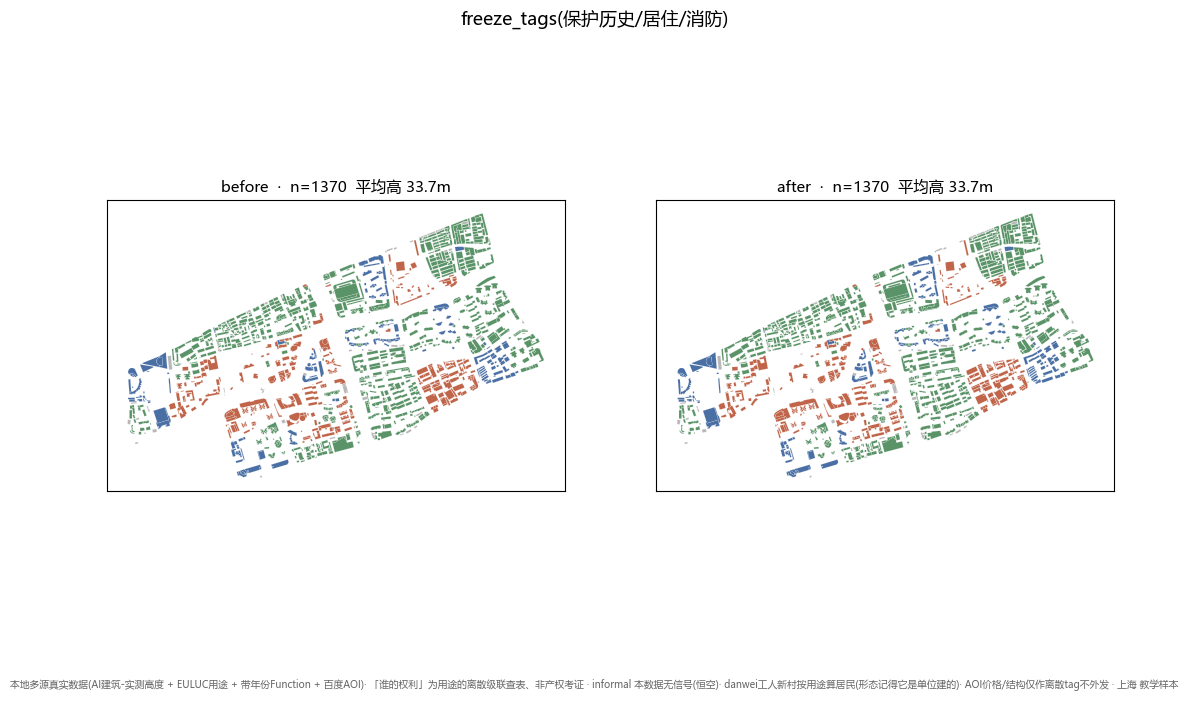

  -> saved out\dapuqiao\Step_04\20260701_171047\05_operator_demo.png


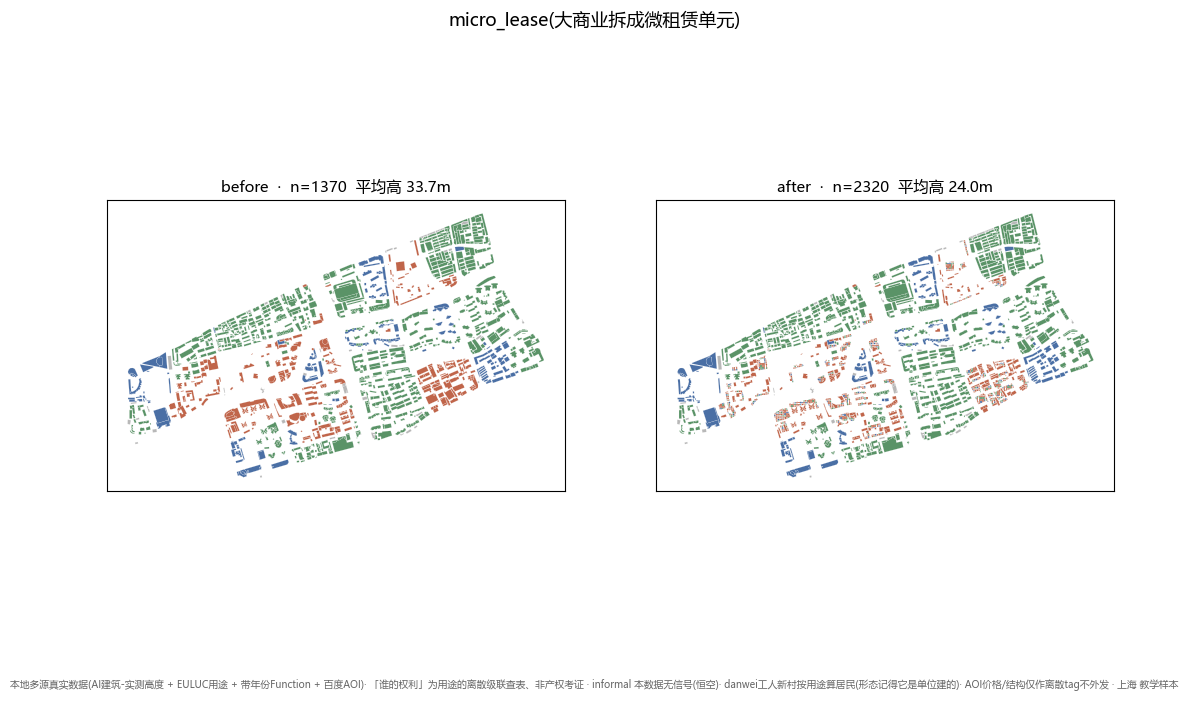

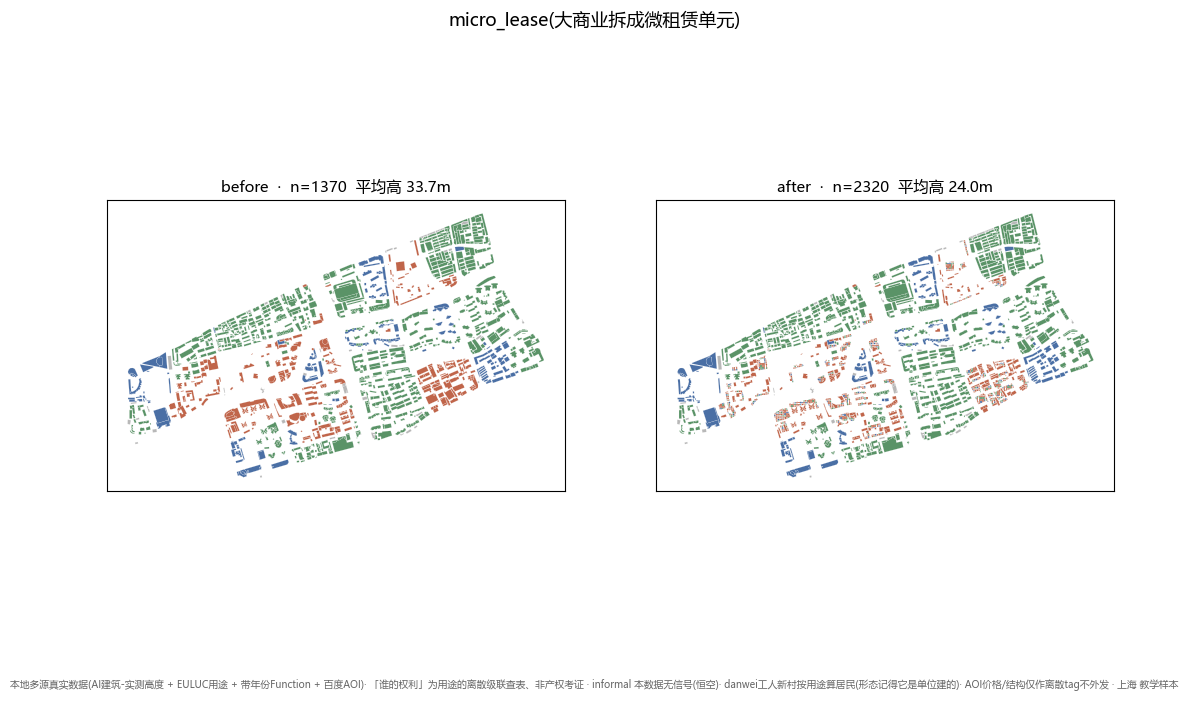

In [5]:
tagged = ops.freeze_tags(recs, tags=["heritage", "residential_core", "emergency_access"])
plots.operator_demo(recs, tagged, "freeze_tags(保护历史/居住/消防)", color="sh")

micro = ops.micro_lease(tagged, target=["developer"], above_m2=500, cell_m2=80,
                       affordable_ratio=0.35, local_service_ratio=0.20, culture_ratio=0.15,
                       min_h=6, max_h=18, seed=42)
plots.operator_demo(tagged, micro, "micro_lease(大商业拆成微租赁单元)", color="sh")


  -> saved out\dapuqiao\Step_04\20260701_171047\06_operator_demo.png


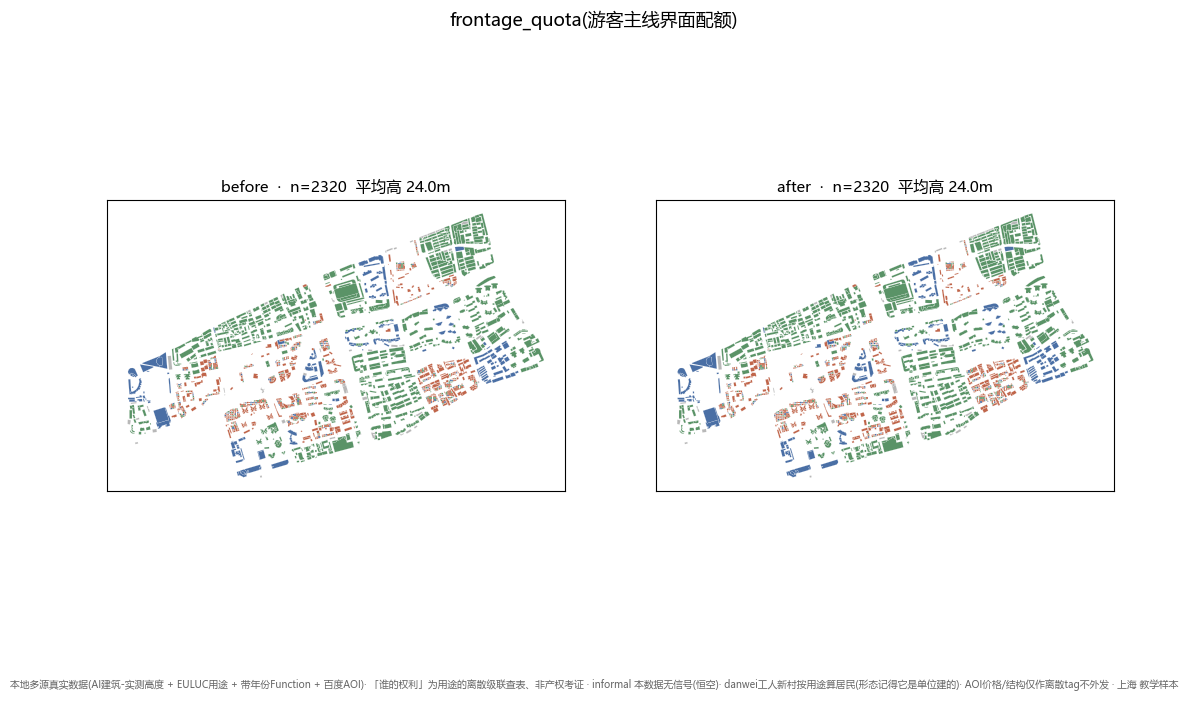

  -> saved out\dapuqiao\Step_04\20260701_171047\07_operator_demo.png


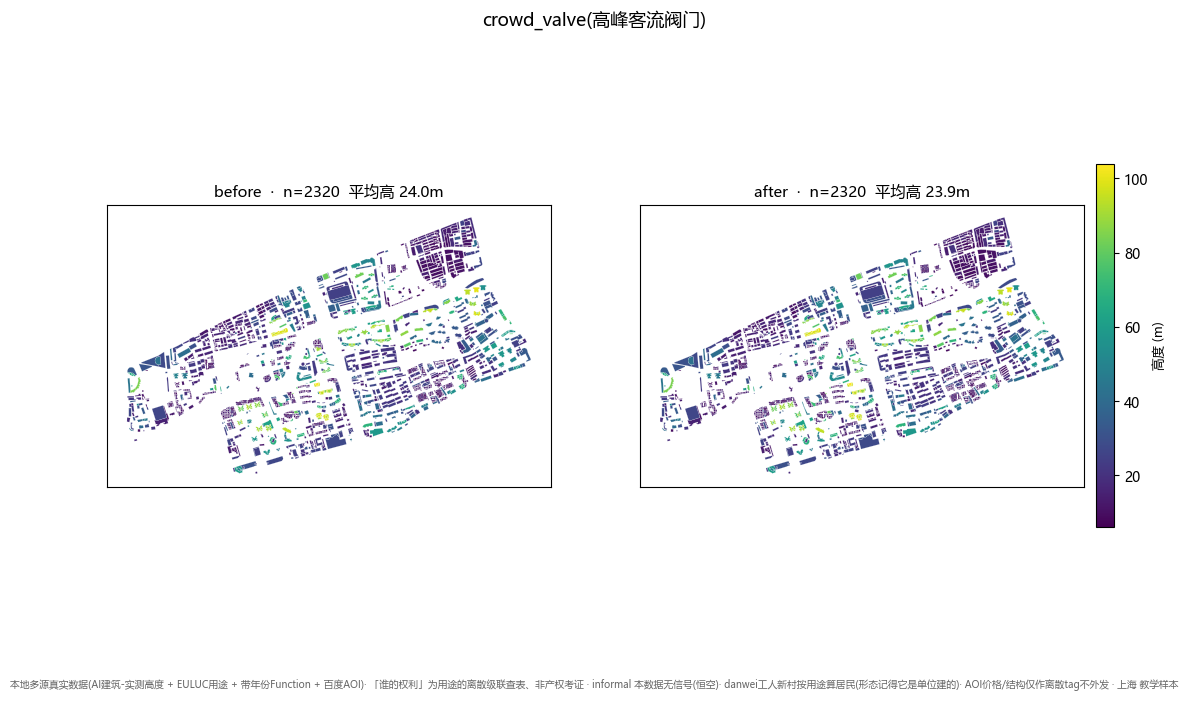

  -> saved out\dapuqiao\Step_04\20260701_171047\08_operator_demo.png


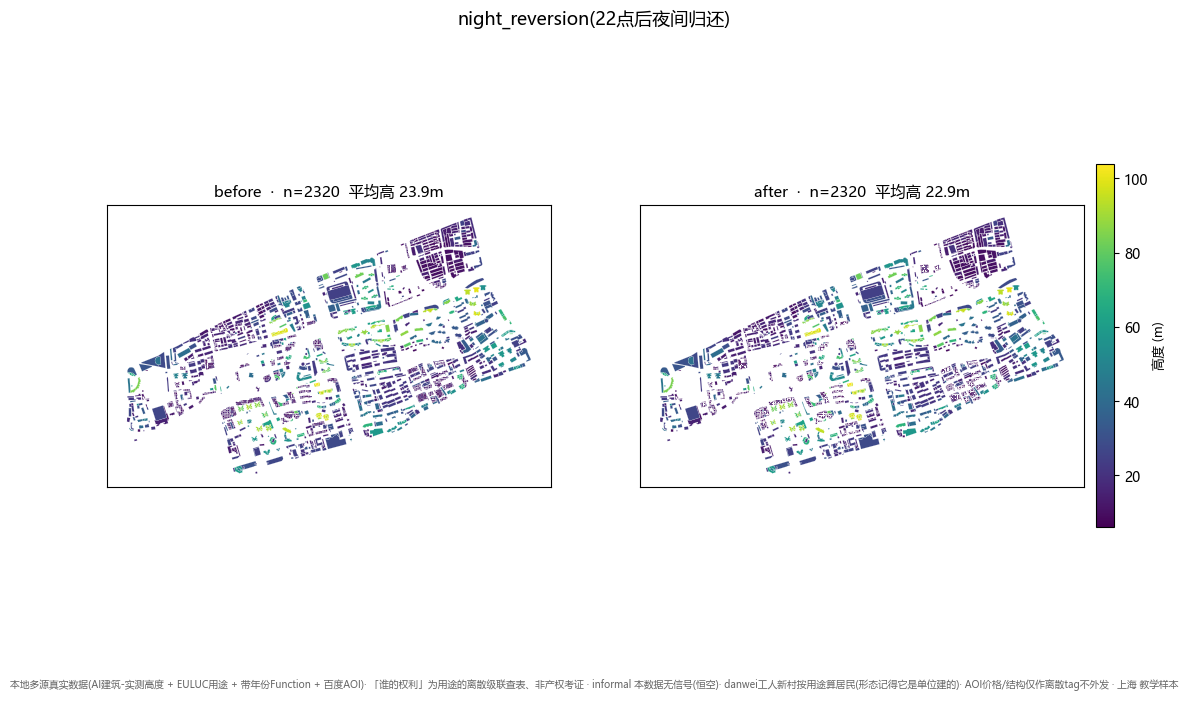

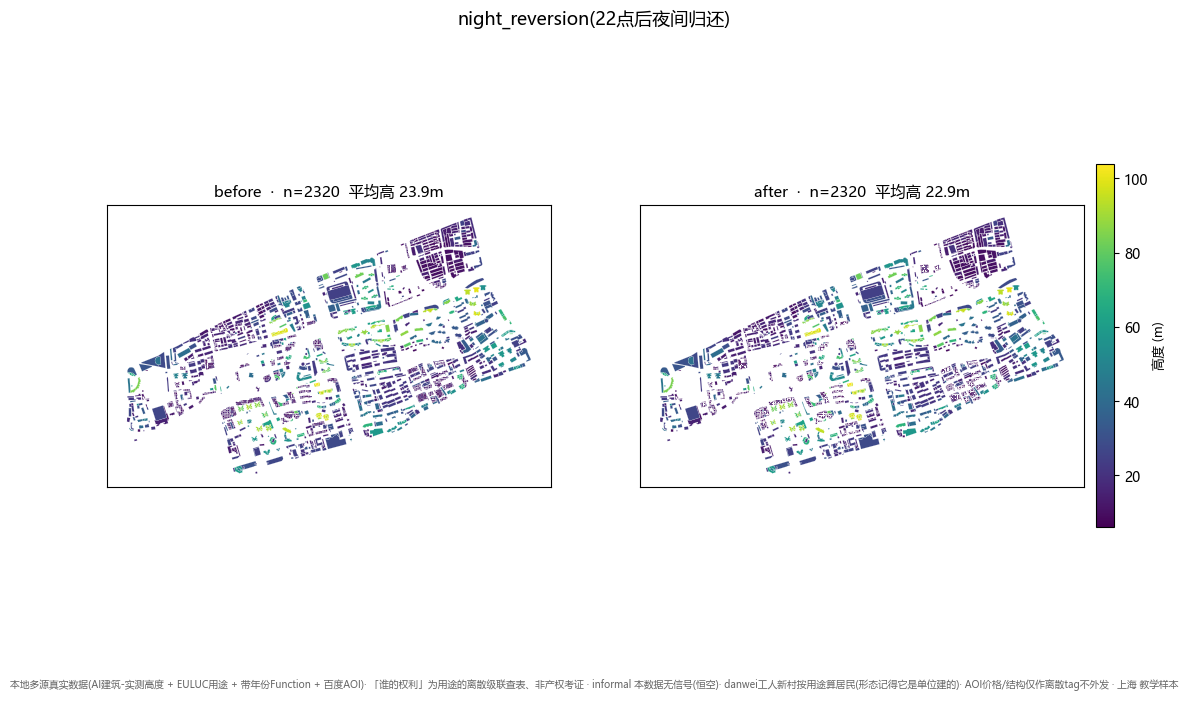

In [6]:
frontage = ops.frontage_quota(micro, primary_routes="tourist_spine", frontage_buffer_m=8,
                            max_tourism_ratio=0.45, min_local_service_ratio=0.15,
                            min_micro_shop_ratio=0.25, min_culture_ratio=0.15, seed=42)
plots.operator_demo(micro, frontage, "frontage_quota(游客主线界面配额)", color="sh")

valved = ops.crowd_valve(frontage, route="tourist_spine", crowd_threshold=0.75,
                         one_way_links=True, protect_tags=["resident_gate", "emergency_access"],
                         relief_nodes=3)
plots.operator_demo(frontage, valved, "crowd_valve(高峰客流阀门)", color="h")

night = ops.night_reversion(valved, start_hour=22, quiet_buffer_m=10,
                            commercial_shutdown_ratio=0.60,
                            protect_tags=["residential_core", "resident_gate"])
plots.operator_demo(valved, night, "night_reversion(22点后夜间归还)", color="h")


## 四、打浦桥权力体制 = 算子的配方(`regimes.yaml`)
把几个动词**按序串起来**,就是一种权力如何重写田子坊弄堂。这里使用 4 种情境:

| 情境 | 谁优先 | 主要矛盾 |
|---|---|---|
| `tourism_capture` | 文旅运营、商业资本、游客流量 | 消费效率会不会压缩居民生活与边缘小商户? |
| `everyday_life_first` | 居民、社区治理、消防安全 | 居民生活优先会不会削弱街区文化活力? |
| `heritage_micro_economy` | 历史建筑、小商户、创意工作者 | 历史里弄能否避免被大商业统一整合? |
| `negotiated_24h_alley` | 不同时间下不同主体轮流优先 | 如何让游客、商业、居民与安全系统共用同一套弄堂? |


In [7]:
DAPUQIAO_REGIME_NAMES = [
    "tourism_capture",
    "everyday_life_first",
    "heritage_micro_economy",
    "negotiated_24h_alley",
]
all_regs = ops.load_regimes()
regs = {name: all_regs[name] for name in DAPUQIAO_REGIME_NAMES}
prints.regimes(regs)


【旅游流量资本主导】商业界面强化、游客主线集中、外围开发强度上升、边缘支弄与日常空间被弱化。
   配方: freeze → split_to_towers → slim → densify
【居民安全与日常生活优先】高度变化温和、居民生活核心稳定、公共通行空间增加、商业扩张受控。
   配方: freeze → open_ground → level
【遗产与小商户共生】细粒度经营单元增加、中低层尺度、商业体量分散、历史里弄保持生活性与文化生产能力。
   配方: freeze_tags → micro_lease → frontage_quota
【24小时协商弄堂】历史与居民核心受保护、细粒度经营共存、游客流线可调节、夜间空间归还、公共安全与文化活力并行。
   配方: freeze_tags → micro_lease → frontage_quota → crowd_valve → night_reversion


## 五、四种情境 → 四种可协商形态(同色阶横比)
同一批打浦桥建筑,套四种权力体制。**形态差异不是换了数据,纯粹来自「谁优先、在什么时间优先、用什么动词协商」。**


  -> saved out\dapuqiao\Step_04\20260701_171047\09_regime_compare.png


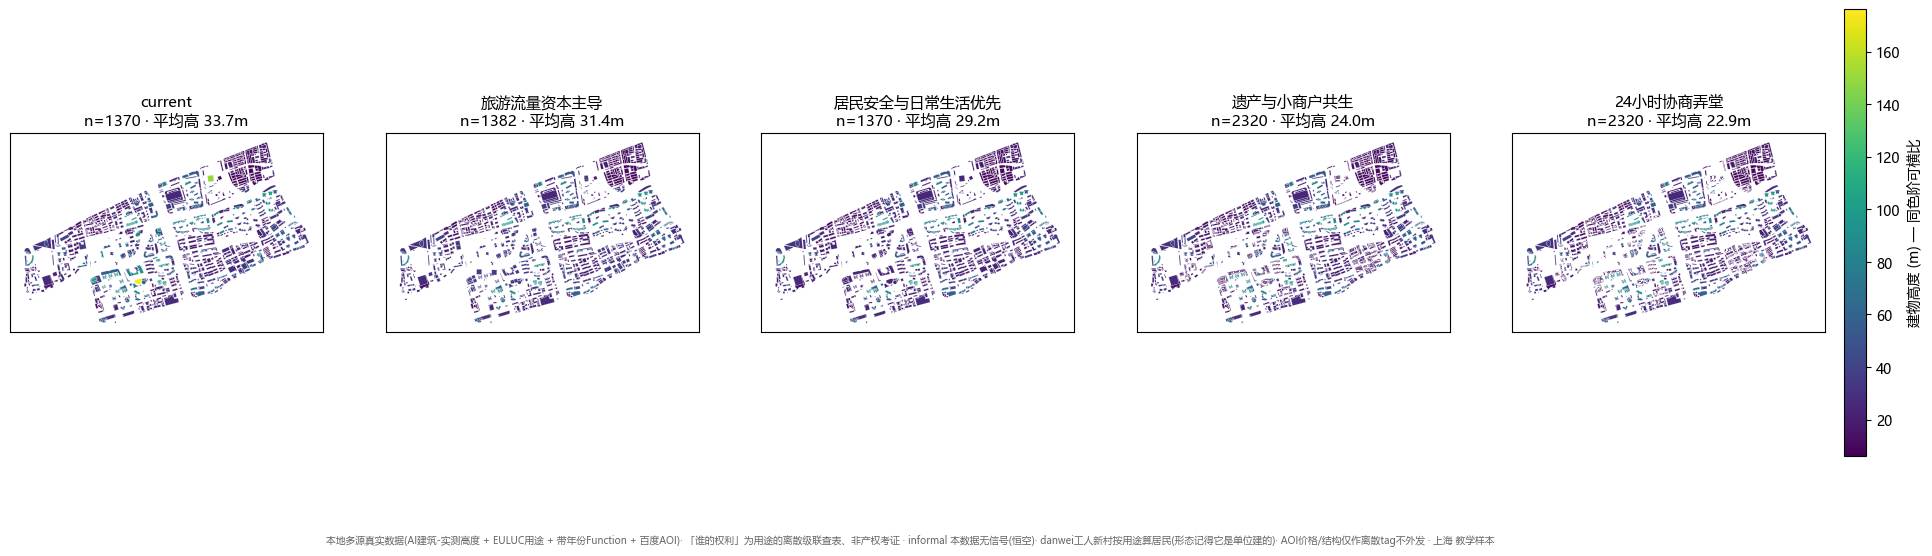

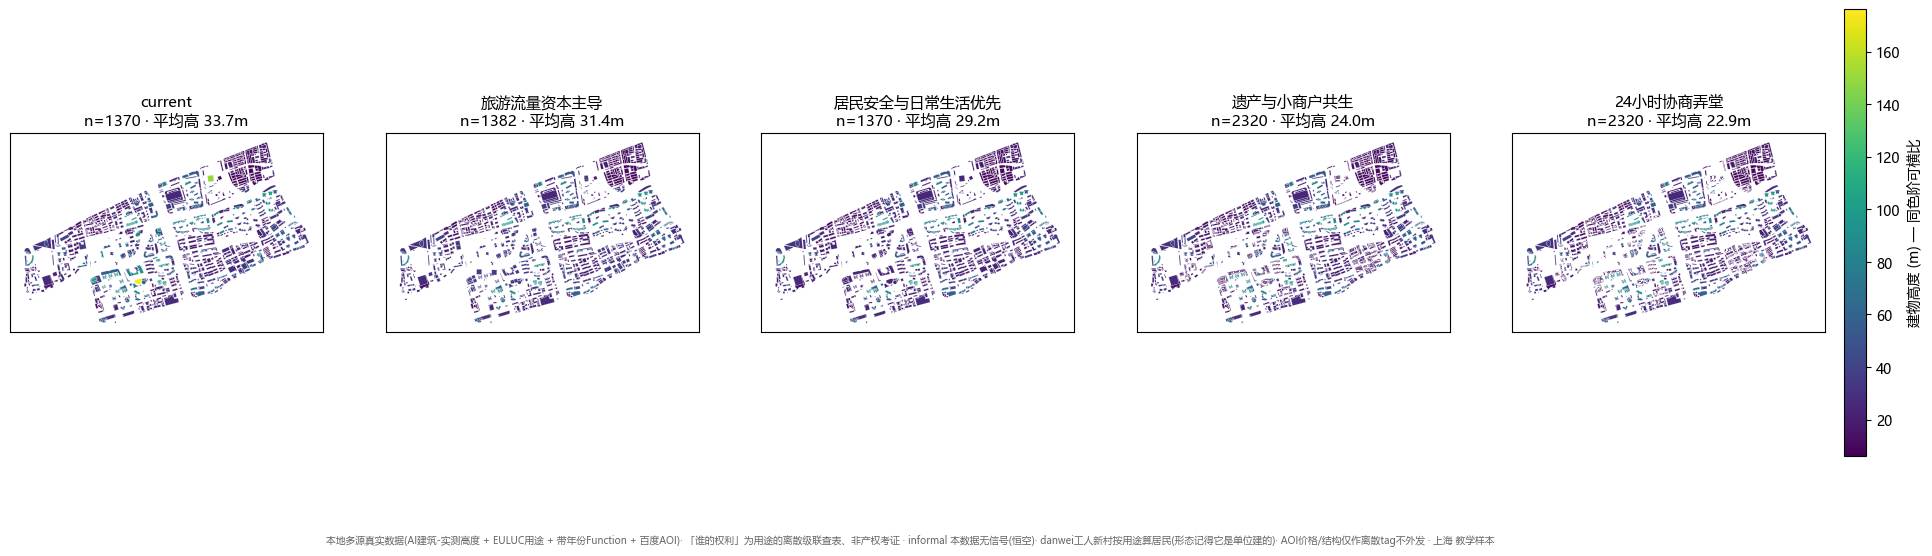

In [8]:
after = {n: ops.apply_regime(recs, regs[n]) for n in regs}
labels = {n: regs[n]["label"] for n in regs}
plots.regime_compare(recs, after, labels=labels)

## 六、情境计算:形态指纹(measure.py 量化)
肉眼之外,用指标比较每种情境的「指纹」:旅游资本主导会提高商业体量强度;居民日常优先会让变化更温和;遗产与小商户共生会增加细粒度单元;24小时协商弄堂会同时叠加细分、疏散与夜间归还。


  -> saved out\dapuqiao\Step_04\20260701_171047\10_fingerprint_bars.png


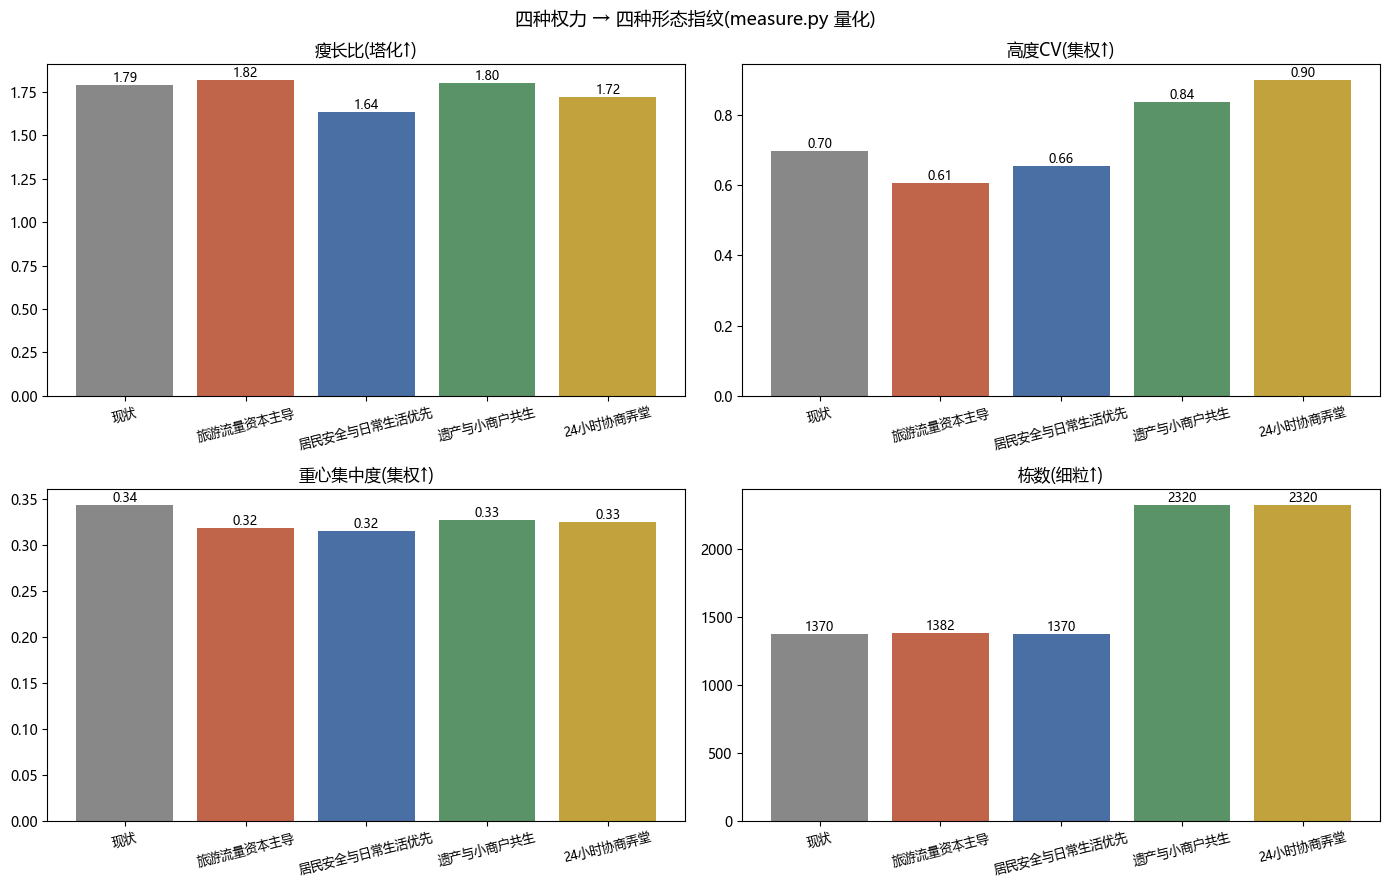

  现状                   瘦长 1.79 · 高度CV 0.70 · 重心集中 0.34 · 栋数 1370
  旅游流量资本主导             瘦长 1.82 · 高度CV 0.61 · 重心集中 0.32 · 栋数 1382
  居民安全与日常生活优先          瘦长 1.64 · 高度CV 0.66 · 重心集中 0.32 · 栋数 1370
  遗产与小商户共生             瘦长 1.80 · 高度CV 0.84 · 重心集中 0.33 · 栋数 2320
  24小时协商弄堂             瘦长 1.72 · 高度CV 0.90 · 重心集中 0.33 · 栋数 2320


In [9]:
rows, _ = M.compare(recs, after, config.SLUG)
plots.fingerprint_bars(rows, labels={"current": "现状", **labels})
prints.fingerprints(rows, {"current": "现状", **labels})

## 七、权力的几何逻辑对基底不变,但结果在乎基底
本册固定在 `dapuqiao`。如果把 `config.py` 的 `SLUG` 换成 `yuyuan`(里弄)或 `caoyang`(工人新村),同一个 `negotiated_24h_alley` 配方也不会长成一样。

> 权力 × 在地是一场对话,不是盖章。打浦桥的关键不是“旅游/居民谁赢”,而是通行、界面、时间与安全如何被拆成可协商的权利。


## 八、动手:复制粘贴换一个算子
算子就是 `recs -> recs` 的纯函数。下面**在 notebook 里**定义一个你自己的算子、登记、用进配方——
不必改 `engine/`。完整模板与说明见 **`算子替换指南.md`**。

  -> saved out\dapuqiao\Step_04\20260701_171047\11_operator_demo.png


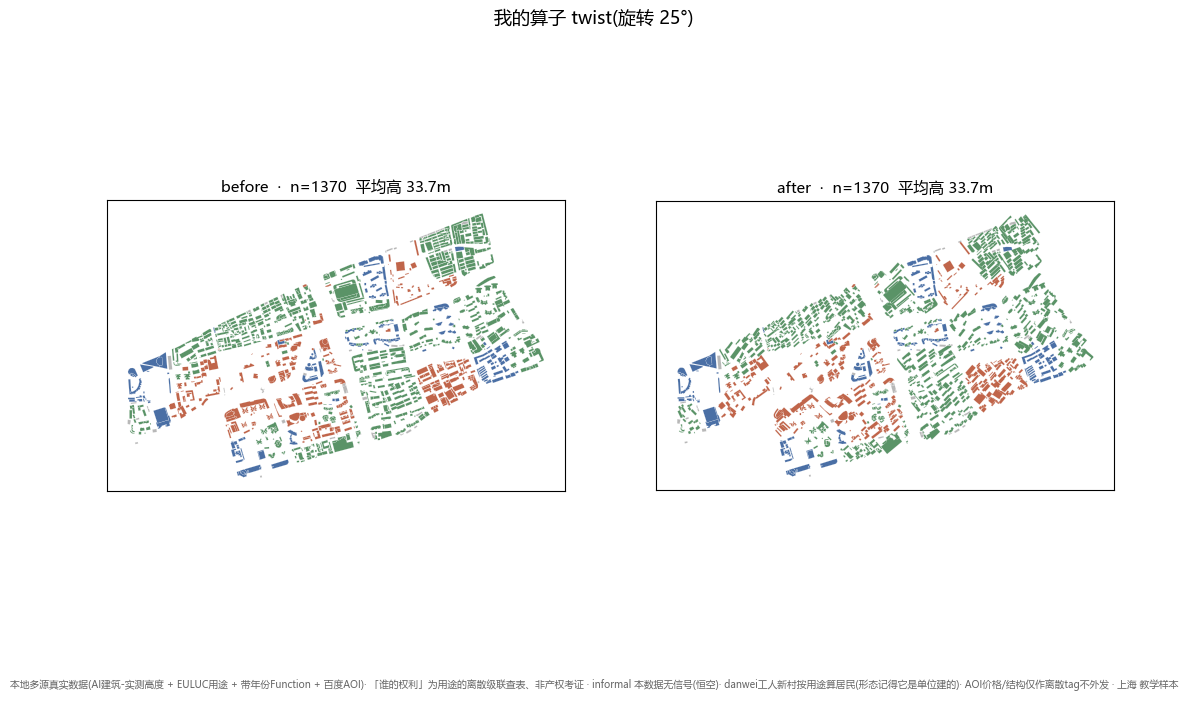

现在 OPS 里多了: True


In [10]:
import shapely.affinity as aff

def twist(recs, target, deg=18):
    """我的算子:把目标楼的 footprint 旋转 deg 度(示范——你可以换成任何形态操作)。"""
    out = [dict(r) for r in recs]
    for r in out:
        if r["sh"] in target and not r.get("frozen"):
            r["geom"] = aff.rotate(r["geom"], deg, origin="centroid")
    return out

ops.register("twist", twist)                       # 登记到算子表(运行时,不改文件)
a3 = twist(b, target=["resident", "developer"], deg=25)
plots.operator_demo(b, a3, "我的算子 twist(旋转 25°)")
prints.registered("twist")

**用进配方**:把任意算子写进一条 `steps`,`apply_regime` 就会按序施加它——和内置算子完全平权。
```yaml
my_regime:
  steps:
    - {op: freeze_tags, tags: [heritage, residential_core, emergency_access]}
    - {op: micro_lease, target: [developer], cell_m2: 80}
    - {op: crowd_valve, route: tourist_spine, crowd_threshold: 0.75}
    - {op: night_reversion, start_hour: 22, quiet_buffer_m: 10}
```
> 这就是这套框架的核心承诺:**权力体制 = 算子的配方,而算子可教、可改、可复制粘贴。**

## 诚实边界
这些 regime → 形态是**教学假设 / 可争论的语言**,不是经验断言或真实规划预测。`heritage`、`tourist_spine`、`resident_gate` 等标签在本练习里由现有 footprint、stakeholder 与空间位置作启发式标记,用于讨论协商逻辑,不等于真实产权、消防审查或运营方案。零 AI 推断。
